# Project 03: Monte Carlo Simulation of Uranium Fission
**Name:** Alex Kauffman

### Research Question:

**How does the time evolution of neutron population growth depend on the enrichment of Uranium-235 in the Fermi Model, and what is the critical time required to reach a supercritical state across different enrichment levels?**

### Starting Assumptions:

**Homogeneous solution**
- We will assume the solution is homogeneously mixed, such that there is an equal distribution of the neutrons throughout the box sample of Uranium
- This allows for accurate random walks to take place that resemble the give parameters to the code

**Fissility of Uranium-238** 
- Assume that Uranium 238 is a fissile material, but that it does not release any thermal neutrons and will thus represent an absorbing property in this simulation which does not contribute to the reaction
- In reality it is an important medium to facilitate nuclear reactions

**Nature of Uranium-235**
- Assume that each Uranium-235 atom releases exactly two thermal neutrons each
- In reality, the range of re-emission of thermal neutrons is anywhere from 1-4, but for simplicity, we will assume two
- Also assume that each Uranium-235 atom will necessarily release the two thermal neutrons

**Natural abundance**
- Assume that the natural abundance of the Uranium isotopes directly corelates to the probability of it being absorbed by a random sample of Uranium
- If the sample is enriched, the abundance goes up, and the probability with it
- Assume that a random sample of Uranium is made up of only Uranium-235 and Uranium-238, as all other isotopes are of negligable natural abundance relative to these two isotopes

**Mean Free Path**
- Assume mean free path is constant, no matter the enrichment level of Uranium-235
- This will help quantify the results of the Uranium-235 enrichment without getting confusion from other changing parameters within a given calculation

- In this simplified model, we do not explicitly track the number of  235U nuclei or even assume a fixed number of them. 
- Instead, the focus is solely on the behavior of the thermal neutrons and their ability to sustain a chain reaction.
- The simulation starts with an initial number, N0 of thermal neutrons, randomly distributed within the sample.
- These neutrons travel in random directions given by a random walk, and may either:
- Be absorbed by 235U nucleus if they remain within the sample (we assume necessary absorption) triggering fission and releasing two more neutrons, or they escape the sample and be lost.
- After that, two more thermal neutrons will be re-emitted from the uranium atom that absorbed the initial thermal neutron in the next *generation* of fission 
$$ k_{n,n+1} = \frac{N_{n+1}}{N_n} $$

Fermi describes a quantity called the multiplication factor, k, to characterize the steady-state behaviour of the nuclear chain reaction. This quantity represents the average number of neutrons from each fission event that cause further fission events, with the following three categories:

Subcritical (ie. the reaction will die out)

$$ k < 1 $$ 

Critical (ie. the reaction is self-sustaining)

$$ k=1 $$

Supercritical (ie. the reaction will grow exponentially)

$$ k > 1 $$

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
a = 0.50  # Side length of the Uranium sample cube in meters
mean_free_path = 0.15  # Mean free path in meters
num_neutrons_initial = 250  # Number of initial neutrons (N0)
num_generations = 3  # Number of generations to simulate
neutrons_per_fission = 2  # Number of neutrons produced per fission event

frequency = []
k_values = []




# This function simulates a random distribution by randomly placing each neutron within the cube's bounds using polar coordinates
# It then returns us how many are absorbed and how many make it out of the cube's bounds
def simulate_neutron_generation(initial_positions, side_length):

    
    # This will calculate how many neutrons are being simulated based on the rows given by initial positions
    num_neutrons = len(initial_positions)

    
    
    # Generate random travel directions in spherical coordinates (from project intro)
    phi = np.random.uniform(0, 2 * np.pi, num_neutrons)  # Azimuthal angle (0 to 2π for a full circle in the xy-plane)
    costheta = np.random.uniform(-1, 1, num_neutrons)    # Cosine of polar angle (uniformly samples z-axis range)
    theta = np.arccos(costheta)  # Converts cosθ into θ (polar angle from 0 to π)


    
    # Convert spherical coordinates to Cartesian unit vectors
    # This converts (r, θ, φ) to (x, y, z) using standard spherical coordinate formulas
    # vstack combines the x, y, z components into a single 2D array with rows for each neutron
    directions = np.vstack((
        np.sin(theta) * np.cos(phi),  # x-component of the direction vector
        np.sin(theta) * np.sin(phi),  # y-component of the direction vector
        np.cos(theta)                # z-component of the direction vector
    )).T  # Transpose to make each row a single neutron's direction vector (x, y, z)

    

    # The distance the neutron travels based on the exponential distribution model
    # The distances are randomly sampled with a mean of `mean_free_path` using an exponential decay function
    distances = -mean_free_path * np.log(np.random.random(num_neutrons))

    

    # Calculate final positions after traveling the distance in the given direction
    # This calculates the position of each neutron after traveling `distances` in its respective direction
    # `distances[:, None]` reshapes distances into a column vector to allow broadcasting with `directions`
    final_positions = initial_positions + distances[:, None] * directions


    
    # Check if the final positions are within the cube (absorbed neutrons)
    # Neutrons within the cube are considered to have been absorbed and will initiate new fissions
    absorbed = (
        (final_positions[:, 0] >= 0) & (final_positions[:, 0] <= side_length) &
        (final_positions[:, 1] >= 0) & (final_positions[:, 1] <= side_length) &
        (final_positions[:, 2] >= 0) & (final_positions[:, 2] <= side_length)
    )

    

    # Return the positions of absorbed neutrons so we can base the next generation of decay off of these positions
    absorbed_positions = final_positions[absorbed]
    return absorbed_positions







# Function to run the simulation over multiple generations
def run_simulation(num_initial_neutrons, num_generations, side_length):
    # Generate initial positions of neutrons uniformly within the cube
    # This creates an array of random (x, y, z) positions for the initial neutrons
    initial_positions = np.random.uniform(0, side_length, (num_initial_neutrons, 3))
    generation_counts = [num_initial_neutrons]  # List to track neutron counts per generation


    

    # Simulate each generation
    for gen in range(num_generations):  # Simulate for the specified number of generations
        # Determine the positions of absorbed neutrons
        absorbed_positions = simulate_neutron_generation(initial_positions, side_length)  # Call previous function



        # Calculating the number of neutrons produced in the next generation
        # The number of absorbed neutrons determines how many new neutrons are produced
        num_neutrons_next = len(absorbed_positions) * neutrons_per_fission


        
        # Append to the list of generation counts
        generation_counts.append(num_neutrons_next)


        
        # Generate positions for the next generation of neutrons
        # Each absorbed neutron spawns `neutrons_per_fission` new neutrons at the same position
        initial_positions = np.repeat(absorbed_positions, neutrons_per_fission, axis=0)

    return generation_counts




# Initialize dictionaries to store k values and their frequencies for each generation
k_values_by_generation = {}
frequency_by_generation = {}




# Function to calculate multiplication factors over multiple trials
def calculate_multiplication_factors(num_initial_neutrons, num_generations, side_length, trials=250):
    # Making a list to store the k-values of each generation, to append later
    k_values_per_generation = [[] for _ in range(num_generations)]

    

    # Run trials
    for i in range(trials):  # For each trial, simulate the generations
        generation_counts = run_simulation(num_initial_neutrons, num_generations, side_length)

        

        # Calculate k for each generation and store
        for gen in range(1, num_generations + 1):  # Start at generation 1 (0 -> 1, 1 -> 2, etc.)
            k = generation_counts[gen] / generation_counts[gen - 1]
            k_values_per_generation[gen - 1].append(k)


    
    # Take the mean and standard deviation of the k values for their respective generation
    k_stats = [(np.mean(k_vals), np.std(k_vals)) for k_vals in k_values_per_generation]

    

    for gen, k_vals in enumerate(k_values_per_generation, start=1):
        # Initialize lists for this generation
        k_values_by_generation[gen] = []
        frequency_by_generation[gen] = []

        

        # Calculate frequency distribution for each k value
        for k in k_vals:
            if k in k_values_by_generation[gen]:  # If the k value is already stored
                index = k_values_by_generation[gen].index(k)
                frequency_by_generation[gen][index] += 1  # Increment the frequency
            else:  # If the k value is new, add it to the list
                k_values_by_generation[gen].append(k)
                frequency_by_generation[gen].append(1)

    

    return k_stats, k_values_per_generation, frequency_by_generation




# Function to plot histograms of k-values for each generation
def plot_k_histograms(k_values_per_generation, num_generations, num_trials):
    plt.figure(figsize=(12, 8))
    for gen in range(num_generations):
        plt.subplot(1, num_generations, gen + 1)  # Create subplots for each generation
        plt.hist(k_values_per_generation[gen], bins=20, color='blue', edgecolor='black', alpha=0.7)
        mean_k = np.mean(k_values_per_generation[gen])  # Calculate mean k for this generation
        std_k = np.std(k_values_per_generation[gen])  # Calculate standard deviation of k
        plt.title(f"Generation {gen} to {gen+1}\nMean k = {mean_k:.3f} ± {std_k:.3f}")
        plt.xlabel("Multiplication Factor (k)")
        plt.ylabel("Frequency")
        plt.grid(axis='y')  # Add grid lines to y-axis
    plt.suptitle(f"N0 = {num_neutrons_initial}, Trials = {num_trials}")  # Overall title for the plot
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit everything
    plt.show()

    return



# Set parameters for the simulation
num_trials = 250  # Number of trials for averaging

# Run the simulation and calculate k values
k_results, k_values_per_generation, frequency_by_generation = calculate_multiplication_factors(num_neutrons_initial, num_generations, a, trials=num_trials)


# Display results
#for gen, (mean_k, std_k) in enumerate(k_results, start=1):
  #  print(f"Generation {gen} -> Mean k: {mean_k:.5f}, Std k: {std_k:.5f}")
    

# Plot the histograms
#plot_k_histograms(k_values_per_generation, num_generations, num_trials)


## k Values in a Natural Sample of Uranium-235 and Uranium-238:

A sample of Uranium is made of many different isotopes. We therefore **must not assume** that a Uranium atom which expells two thermal neutrons will recapture a given number of neutrons in the following generation. We must look at the purity of a given sample to determine the probabilities that the neutron will be asborbed by some specific isotope.

**Purity** refers to the probability that a neutron contained in the sample after a random walk will be captured by a 235Uranium sample, and thus undergo another round of fusion. We had been treating this factor as p = 1.0, indicating that every neutron remaining in the sample would cause fission. However, in more realistic scenarios, this probability is less than 1 due to the presence of other materials and isotopes that can absorb neutrons without causing fission.

We can simulate the contents of a sample of Uranium by looking at its relative abundance in space. Let's say we have some random sampe of Uranium. We can assume that the amount of each type of Uranium isotope is given by its relative abundance in space:

Relative Abundances of Uranium:

$$^{235}U = 0.0720 $$
$$^{238}U = 0.928 $$
$$^{other}U \approx 0 $$

From the Fermi Experiment:

$$ ^{235}U -> 2n $$

$$ ^{238}U -> (several steps) -> ^{206}Pb$$

$ ^{235}U $ is a fissile atom, as defined by the fermi experiment. When it absorbs a neutron, it will decay and release two more thermal neutrons. Fissile implies that Uranium can sustain a nuclear chain reaction when it captures a thermal neutron. It splits into smaller nuclei (fission products), releasing a tremendous amount of energy along with more neutrons to perpetuate the chain reaction.

$ ^{238}U $ is Fertile. While Uranium-238 can absorb a fast neutron, it does not undergo fission readily. Instead, it typically captures the neutron, and through a series of slow decay, will turn into $ ^{206}Pb $. This is a stable isotope, which implies that the decay of Uranium-238 cannot be used to sustain and nucler reaction

**Calculating the k value of Uranium-235**

In order to produce a runaway k effect, which is needed to create nuclear weaponry, the sample of Uranium-235 must have a k vlaue much greater than one. Below, we will firstly see what the k value of Uranium-235 will be in its natural abundance form.

We will assume that after the random walk, if the neutron remains within the confined sample, it will get absorbed. However, there are different probabilities for if the neutron will be asborbed by the Uranium-235 isotope, or the Uranium-238 isotope. We can equate the probability of the neutron being absorbed by each respective isotope based on its abundance

$$ P(^{235}U) = \frac{0.0720}{0.928+ 0.0720} = 0.0720 $$
$$ P(^{238}U) = \frac{0.928}{0.928+ 0.0720} = 0.928 $$

In [14]:
def run_simulation_with_probabilities_fixed(num_initial_neutrons, num_generations, side_length, fraction_235U):

    fraction_238U = 1 - fraction_235U
    P_235U = fraction_235U  # Probability of absorption by 235U
    P_238U = fraction_238U  # Probability of absorption by 238U

    #Making our random distribution of positions of neutrons accross the box 
    initial_positions = np.random.uniform(0, side_length, (num_initial_neutrons, 3))
    generation_counts = [num_initial_neutrons]

    for gen in range(num_generations):
        absorbed_positions = simulate_neutron_generation(initial_positions, side_length)
        num_absorbed = len(absorbed_positions)

        # Absorption outcomes is given by the number of absorbed times the probability of it being absorbed respectively. Since total prob = 1 we can calculate 238U from it
        num_absorbed_by_235U = int(num_absorbed * P_235U)
        num_absorbed_by_238U = num_absorbed - num_absorbed_by_235U

        # Calculate neutrons produced by 235U fission
        neutrons_from_235U = num_absorbed_by_235U * neutrons_per_fission
        num_neutrons_next = int(neutrons_from_235U)

        print(f"Generation {gen + 1}: Absorbed by 235U = {num_absorbed_by_235U}, Absorbed by 238U = {num_absorbed_by_238U}")

        # Update neutron counts and positions for the next generation
        # We append the neutrons to the list in order to remember where they are for beginning the following generation
        generation_counts.append(num_neutrons_next)
        #We use np.repeat to repeat each element of an array after themselves
        #It gives back an array of many elements that have the same form as the input array's specified axis so we can use the array again and not affect the origional arrays values
        initial_positions = np.repeat(absorbed_positions, neutrons_per_fission, axis=0)

    # Calculate k values we can use previouos code for this
    for gen in range(1, len(generation_counts)):
        if generation_counts[gen - 1] == 0:
            k = 0
        else:
            k = generation_counts[gen] / generation_counts[gen - 1]
        print(f"Generation {gen}: k = {k:.3f}")

    return generation_counts

# Test the updated simulation
fraction_235U = 0.0072  # Natural abundance of 235U
num_initial_neutrons = 250
num_generations = 1
generations = run_simulation_with_probabilities_fixed(num_initial_neutrons, num_generations, a, fraction_235U)


Generation 1: Absorbed by 235U = 1, Absorbed by 238U = 161
Generation 1: k = 0.008


### Enrichment Levels

Herein lies the probem of having a random sample of Uranium and seeing if it will produce a runaway k effect. This will never happen in an arbitrary example because the fraction of Uranium-235 compared to Uranium-238 is way too small. Typically, there are ways to extract the Uranium-235 from an arbitrary sample. However, for our case, we will investigate what the enrichment level of Uranium-235 must be in order to produce a k-value greater than 1 in order to produce a supercritical reaction in which the reaction will grow exponentially


Below we will calculate the required enrichment level for a sample of Uranium-235 in order to produce a k-value greater than 1 in its first generation, and thus give it the ability to grow exponentially

Critical enrichment found: 235U fraction = 0.7771 with k = 1.017
Critical enrichment found: 235U fraction = 0.7974 with k = 1.045
Critical enrichment found: 235U fraction = 0.8176 with k = 1.079
Critical enrichment found: 235U fraction = 0.8379 with k = 1.087
Critical enrichment found: 235U fraction = 0.8582 with k = 1.128
Critical enrichment found: 235U fraction = 0.8784 with k = 1.150
Critical enrichment found: 235U fraction = 0.8987 with k = 1.168
Critical enrichment found: 235U fraction = 0.9190 with k = 1.192
Critical enrichment found: 235U fraction = 0.9392 with k = 1.220
Critical enrichment found: 235U fraction = 0.9595 with k = 1.266
Critical enrichment found: 235U fraction = 0.9797 with k = 1.286
Critical enrichment found: 235U fraction = 1.0000 with k = 1.312


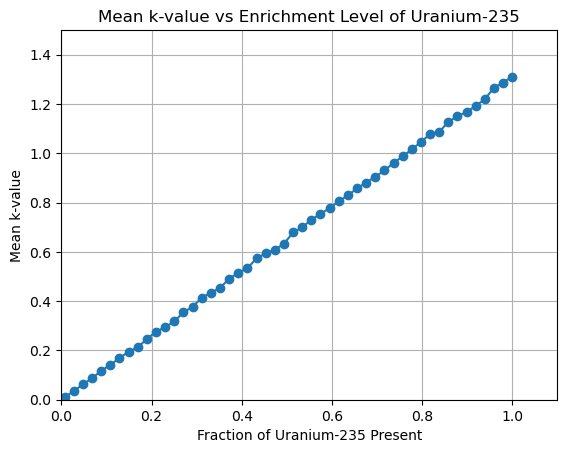

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
a = 0.50  # Side length of the Uranium sample cube in meters
mean_free_path = 0.15  # Mean free path in meters
num_neutrons_initial = 250  # Number of initial neutrons
num_generations = 3  # Number of generations to simulate
neutrons_per_fission = 2  # Number of neutrons produced per fission event

# Updated simulation with explicit probabilities and travel distances
def run_simulation_with_probabilities(num_initial_neutrons, num_generations, side_length, fraction_235U):
    """
    Simulates neutron absorption and multiplication using explicit probabilities for 235U and 238U.
    We can use our previous code but we need to tweak it slightly to fit with the new probability distributions
    """
    # Absorption outcomes is given by the number of absorbed times the probability of it being absorbed respectively. Since total prob = 1 we can calculate 238U from it
    fraction_238U = 1 - fraction_235U
    P_235U = fraction_235U  # Probability of absorption by 235U
    P_238U = fraction_238U  # Probability of absorption by 238U

    # Generate initial positions for neutrons within the cube
    initial_positions = np.random.uniform(0, side_length, (num_initial_neutrons, 3))
    generation_counts = [num_initial_neutrons]

    for gen in range(num_generations):
        num_neutrons = len(initial_positions)

        # Generate random travel directions in spherical coordinates
        phi = np.random.uniform(0, 2 * np.pi, num_neutrons)  # Azimuthal angle
        costheta = np.random.uniform(-1, 1, num_neutrons)  # Cosine of polar angle
        theta = np.arccos(costheta)  # Polar angle

        # Convert it back to cartesian coordinates
        directions = np.vstack((
            np.sin(theta) * np.cos(phi),  # x-component
            np.sin(theta) * np.sin(phi),  # y-component
            np.cos(theta)                # z-component
        )).T

        # Sample travel distances based on the exponential distribution - do random walk
        distances = -mean_free_path * np.log(np.random.random(num_neutrons))

        # Calculate final positions after traveling the distances
        final_positions = initial_positions + distances[:, None] * directions

        # Determine absorbed neutrons (inside the cube bounds)
        absorbed = (
            (final_positions[:, 0] >= 0) & (final_positions[:, 0] <= side_length) &
            (final_positions[:, 1] >= 0) & (final_positions[:, 1] <= side_length) &
            (final_positions[:, 2] >= 0) & (final_positions[:, 2] <= side_length)
        )
        absorbed_positions = final_positions[absorbed]
        num_absorbed = len(absorbed_positions)

        # Determine absorption outcomes
        #Chat GPT helps fix this for calculating the respective probabilities becaus code was giving errors when I used the other version
        #Basically does the same thing because for the given num absorbed it produces the randomness to fit the probabilities and then keeps track of final positions
        num_absorbed_by_235U = np.sum(np.random.random(num_absorbed) < P_235U)
        num_absorbed_by_238U = num_absorbed - num_absorbed_by_235U

        # Calculate neutrons produced by 235U fission for the next generation of iteration 
        neutrons_from_235U = num_absorbed_by_235U * neutrons_per_fission
        num_neutrons_next = int(neutrons_from_235U)

        # Update neutron counts and positions for the next generation
        #np.repeat will create a new array of the same values and type so we can use it again without affect the origional value of the array
        generation_counts.append(num_neutrons_next)
        initial_positions = np.repeat(absorbed_positions, neutrons_per_fission, axis=0)

    return generation_counts

# Test enrichment levels using the updated probabilistic model
def test_enrichment_levels_with_probabilities(num_initial_neutrons, num_generations, side_length, trials, enrichment_levels):
    """
    This code will just run the probabilities simulation for the values we want it to calculate for, and then it will calculate the k value each time too so we can plot it
    """
    results = []

    for fraction_235U in enrichment_levels:
        k_values_per_generation = [[] for _ in range(num_generations)]

        for i in range(trials):
            generation_counts = run_simulation_with_probabilities(num_initial_neutrons, num_generations, side_length, fraction_235U)
            for gen in range(1, num_generations + 1):
                # Avoid division by zero
                if generation_counts[gen - 1] == 0:
                    k = 0
                    #Calculating k values using the general formula and appending to the k values list
                else:
                    k = generation_counts[gen] / generation_counts[gen - 1]
                k_values_per_generation[gen - 1].append(k)

        mean_k = np.mean(k_values_per_generation[0])  # Focus on first generation (0 to 1)
        results.append((fraction_235U, mean_k))

        # Stop if k > 1
        if mean_k > 1:
            print(f"Critical enrichment found: 235U fraction = {fraction_235U:.4f} with k = {mean_k:.3f}")

    return results

# Define enrichment levels to test
enrichment_levels = np.linspace(0.0072, 1, 50)  # Gradual enrichment from natural to weapons-grade

# Run the enrichment test
num_trials = 100
results_probabilities = test_enrichment_levels_with_probabilities(
    num_neutrons_initial, num_generations, a, num_trials, enrichment_levels
)

# Extract results for plotting
enrichment_levels = [result[0] for result in results_probabilities]  # Fraction of Uranium-235
mean_k_values = [result[1] for result in results_probabilities]      # Corresponding mean k-values

# Plot the results
plt.plot(enrichment_levels, mean_k_values, marker='o')
plt.title("Mean k-value vs Enrichment Level of Uranium-235")
plt.xlabel("Fraction of Uranium-235 Present")
plt.ylabel("Mean k-value")
plt.xlim([0, 1.1])
plt.ylim([0, 1.5])
plt.grid(True)
plt.show()


The plot indicates that for any sample of Uranium with Uranium-235 enrichment greater than 77% of the sample, the amount of fissionable material will become greater than the critical mass, resulting in a chain reaction that increases at an accelerating rate. 

In reality, Uranium-235 is extracted from a given sample in order to create a new sample with a higher enrichment level that can have said k value > 1. Thus, we can conclude that for the given dimensions of our sample (the $ 0.5$  X $0.5$  X $0.5$ box), if a new sample with these dimensions is created with at minimum 77% enrichment of Uranium-235, the reaction can create an accelerating reaction to create the nuclear explosion

We canow explore the time evolution of a supercritical reaction. We can model the time it takes for the supercritical reaction to grow exponentially through the following formula:

$$ N(t) = N_0 \times e^ {(k-1) \times \frac{\tau}{t} } $$ where 

$ N(t) $ = Neutron population at time t
$ N_0 $ = Initial neutron population
$ k $ = Neutron multiplication factor
$ \tau $ = Mean neutron lifetime

It is reported that the mean neutron lifetime in a supercritical reaction is $1 \times 10^-6s $

Additionally, in a nuclear chain reaction, the number of neutrons grows exponentially. $10^6$ neutrons is often considered a level where the system has reached a scale large enough to cause significant fission energy release within a short time. This number represents a tipping point where the energy generated becomes dangerous and uncontrollable. We will thus assume the target number of neutrons is $10^6$

We have: 

$$ N(t) = N_0 \times e^ {(k-1) \times \frac{\tau}{t} } $$

$$ \frac{N(t)}{N_0} = e^ {(k-1) \times \frac{\tau}{t} } $$

$$ \ln{\frac{N(t)}{N_0}} = {(k-1) \times \frac{\tau}{t} } $$

$$ t = \tau \times \frac{\ln{\frac{N(t)}{N_0}}}{(k-1)} $$

We will use the previous critical enrichment results for the plot

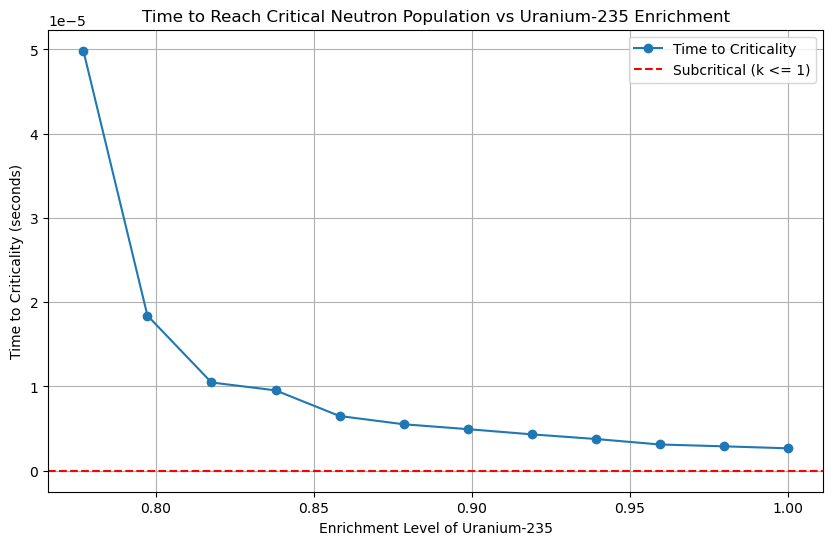

In [5]:
# Constants for the corrected model
tau = 0.1e-6  # Mean neutron lifetime in seconds
initial_neutrons = 250  # Initial neutron population
threshold_neutrons = 1e6  # Neutron population threshold for dangerous reaction

# Time to criticality calculation function
def time_to_criticality(k, N0, tau, threshold):
    """
    This function calculates the time needed to reach the supercritical neutron number based on the initial k value, neutrons, and the threshold of neutrons 
    """
    if k <= 1:
        return None  # Subcritical; will not grow
    return tau * np.log(threshold / N0) / (k - 1)

# Generate data for time evolution
times_to_criticality = []  # Store time to reach critical neutron population

# Use k-values from the simulation results
# Use previous simulation results to show the probabilities
for enrichment, k in results_probabilities:
    if k <= 1:
        times_to_criticality.append(None)  # Subcritical so no criticality reached
    else:
        time_to_threshold = time_to_criticality(k, initial_neutrons, tau, threshold_neutrons)
        times_to_criticality.append(time_to_threshold)

# Plot the corrected time to criticality vs enrichment level
plt.figure(figsize=(10, 6))
plt.plot(enrichment_levels, times_to_criticality, marker='o', label="Time to Criticality")
plt.axhline(y=0, color='red', linestyle='--', label="Subcritical (k <= 1)")
plt.title("Time to Reach Critical Neutron Population vs Uranium-235 Enrichment")
plt.xlabel("Enrichment Level of Uranium-235")
plt.ylabel("Time to Criticality (seconds)")
plt.grid(True)
plt.legend()
plt.show()


The results of the Time to Reach Critical Neutron Population vs Uranium-235 Enrichment plot shows an exponential decay-like curve. The higher the enrichment of Uranium-235, the lower the time needed to reach criticality. Note the scale of the plot, it is of orders of magnitude for time of $ 10^{-5} $. This result shows just how fast the reaction progresses to reach the critical level. It is essentially an instantaneous reaction bust on the shear criticallity of the same and the exponential increase in an already neutron dense system.

The plot's result is as expected. The higher the enrichment, the more supercritical the reaction will become, and thus it will have a larger exponential increase in neutrons per generation. The plot also gives evidence to the validity of this result, as we expect an exponential decay based on the equation and calculation for t.

To further analyze this result, we can compare to see how various enrichment levels capable of creating a runaway neutron effects, increase from generation to generation. We expect the higher enrichment levels to increase more steeply, as they take less time to reach the supercritical level. 

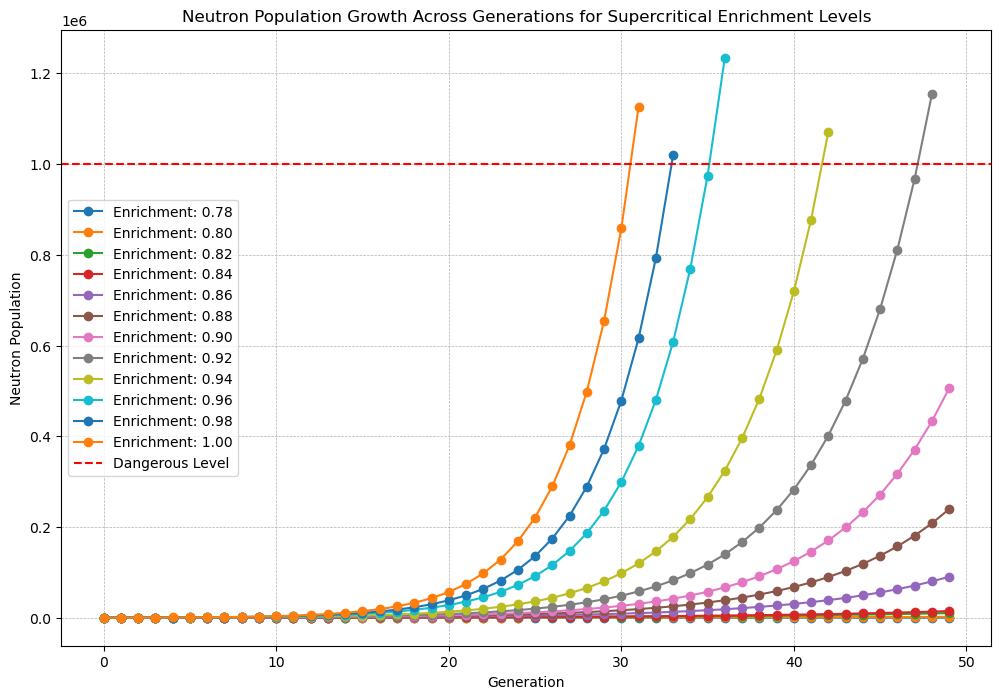

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
threshold_neutrons = 1e6  # Dangerous level
num_generations = 50  # Max generations to simulate
tau = 0.1e-6  # Mean neutron lifetime in seconds
initial_neutrons = 250  # Initial neutron count
neutrons_per_fission = 2  # Neutrons released per fission event

# Function to calculate population growth for each generation
def neutron_population_over_generations(initial_neutrons, num_generations, k):
    """
    Simulates neutron population growth across generations for a given k value.
    """
    population = [initial_neutrons]
    for _ in range(num_generations - 1):
        next_gen_population = population[-1] * k
        population.append(next_gen_population)
        if next_gen_population >= threshold_neutrons:  # Stop if threshold is exceeded
            break
    return population

# Use the k-values from previous simulation
generation_results = {}
for enrichment, k in results_probabilities:  # Reuse simulation results
    if k > 1:  # Only simulate for supercritical cases
        population_growth = neutron_population_over_generations(initial_neutrons, num_generations, k)
        generation_results[enrichment] = population_growth

# Plot neutron population over generations for each enrichment level
plt.figure(figsize=(12, 8))
for enrichment, populations in generation_results.items():
    plt.plot(range(len(populations)), populations, marker='o', label=f"Enrichment: {enrichment:.2f}")

plt.axhline(y=threshold_neutrons, color='red', linestyle='--', label="Dangerous Level")
plt.title("Neutron Population Growth Across Generations for Supercritical Enrichment Levels")
plt.xlabel("Generation")
plt.ylabel("Neutron Population")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

The Neutron Polpulation Growth Across Generations for Supercritical Enrichment Levels plot shows that a higher enrichment level leads to a more steeply increasing curve as generations of the sample increases. The increase seems exponential, which is expected as supercritical k values means that there is an exponentially increasing number of thermal neutrons released per generation of the reaction, and thus the k value will increase to match this result. The Neutron Population axis is on the order of $10^6$, and the dangerous number of neutrons is indicated by the dotted red line across the plot. 

This plot confirms our hypothesis that the higher enrichment level, the less time it will take to the threshold number of neutron population. Higher enrichment levels cause a steeper increase in population accross generations, so for higher enrichment it takes less generations to reach the required threshold of neutrons for a nuclear reaction to take place. The generations needed to reach the threshold is proportional to the time it takes to reach such threshold, as evidence by the higher enrichment levels needing less generations to reach the critical number of neutrons.

### Results:

The results of the enrichment test indicate that the minimum abundance of $^{235}U$ in a given sample of Uranium confined in our pre-defined box must be $77.1$% of the total sample. Any enrichment level above this point will also result in a supercritical reaction, and thus have the ability for nuclear weapon functionality.

Further investigation into the enrichment levels of a Uranium sample reveal that the more enriched the sample is, the quicker it reaches the critical number of neutrons needed for explosion. This level of increase is proportional to a plot of $ \frac{1}{x-1} $. We see diminishing returns in the time it takes to reacj critical neutron count compared to an increase in enrichment of the sample.

We can further investigate the idea of time to neutron criticallity by looking at how supercritical reaction evolve through generations. The Neutron Population Growth Across Generations for Supercritical Levels reveals an exponential increase in the number of neutrons produce per increase in generation. The highest enriched results increase in k value the quickest, which aligns with our results for time to criticallity, confirming the result

## References

- https://en.wikipedia.org/wiki/Plutonium-238
- https://en.wikipedia.org/wiki/Isotopes_of_uranium
- https://en.wikipedia.org/wiki/Nuclear_reactor_physics
- https://www.nuclear-power.com/nuclear-power/fission/prompt-neutrons/prompt-generation-time-mean-generation-time/?utm_source=chatgpt.com

## Appendix 1: Code validation

### A1.1

The first code validation done is to show that the probabilities of Uranium-235 and Uranium-238 are being implemented correctly based on their defined probabilities. As mentioned for the relative abundances of Uranium-238 and Uranium-235, their probabilities should we:

$$ P(^{235}U) = \frac{0.0720}{0.928+ 0.0720} = 0.0720 $$
$$ P(^{238}U) = \frac{0.928}{0.928+ 0.0720} = 0.928 $$

We can confirm these probabilities are being accurately reflected in the simulation by comparing the amount of neutrons absorbed by Uranium-235 and the amount of neutrons absorbed by Uranium-238 in a series of calculations, and taking their average, which should match these probabilities pretty accurately 

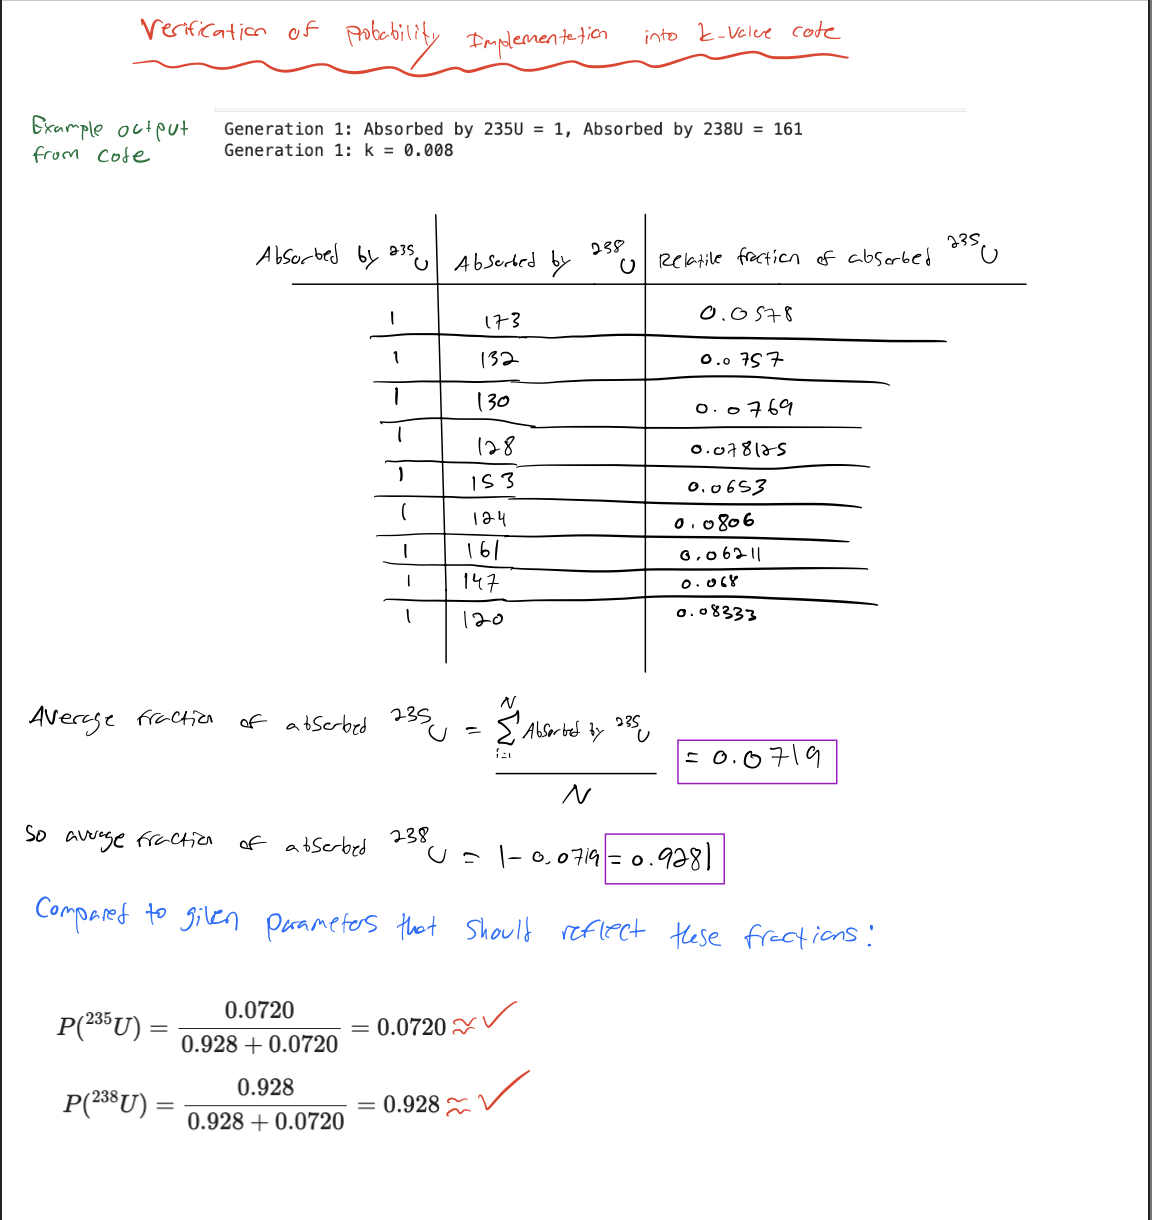

### A1.2: 

The second code validation done was confirming that the Time to Reach Critical Neutron Population vs Uranium-235 Enrichment plot followed an expected distribution. Since the formula of time evolution of a supercritical reaction follows from online research, we can re-order the formula to solve for the variable t. Then, we can plot this graph by looking at how different the different independent variables of the plot will effect the dependent variable t. Thus, when we create this plot in Python, it should follow a similar distribution.

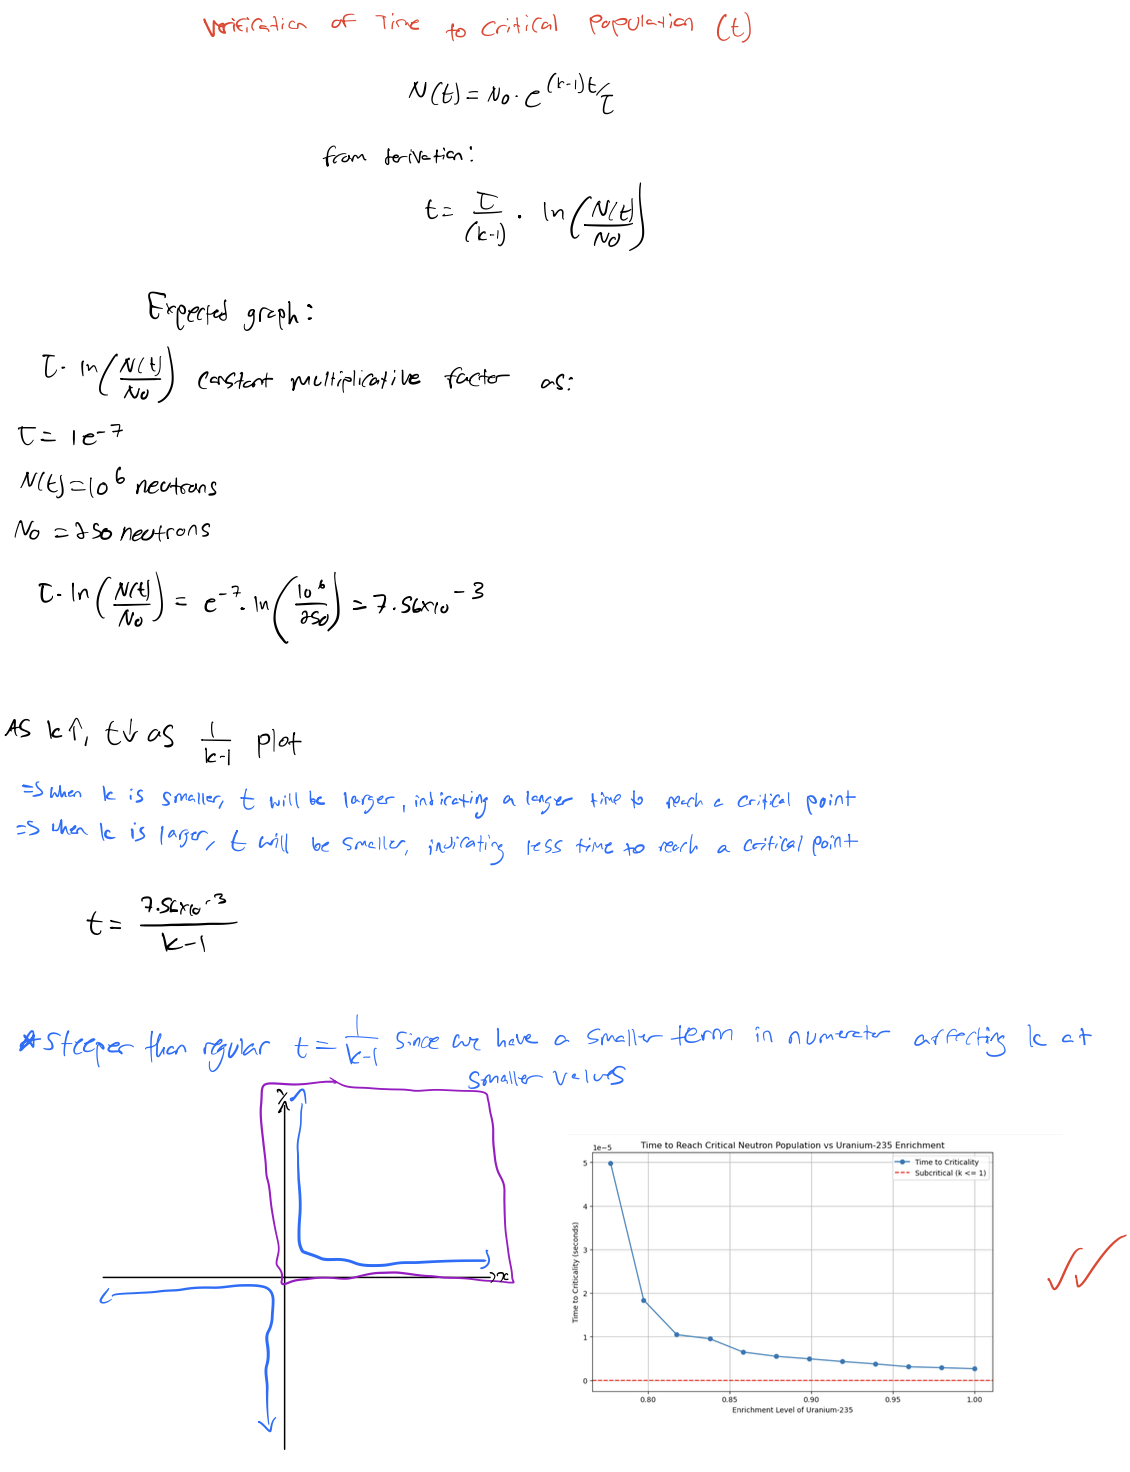

## Appendix 2: Reflection questions

### Reflection 1: Coding Approaches (A)
*(How well did you apply and extend your coding knowledge in this project? Consider steps you took to make the code more efficient, readable and/or concise. Discuss any new-to-you coding techniques, functions or python packages that you learned how to use. Reflect on any unforeseen coding challenges you faced in completing this project.)*

In this project, I applied and extended my coding knowledge by implementing modular and reusable functions to streamline the simulation. For example, the use of functions like simulate_neutron_generation and run_simulation_with_probabilities helped for specific tasks and were called whenever needed, making the code more readable and easier to debug. I also used how to use arrays in a more effective manner. I needed to perform operations on arrays like transposition, and splicing arrays in order to extract information from the arrays. These made the overall code run more efficiently and effectively.

New-to-me techniques included generating spherical coordinate directions for neutron travel and using exponential distributions to simulate random neutron paths. Random walks as a whole were still a relatively new idea to me, but implementing it into this project helped my comfortability with the Monte Carlo method as a whole.

A major unforeseen challenge was having to figure out whether results were simply the results, or a result of faulty coding. Since the cells used to run a code were pretty long comparitively to what I have done before, it took a lot of running smaller cells and building up to create a larger code.

### Reflection 2: Coding Approaches (B)
*(Highlight an aspect of your code that you feel you did particularily well. Discuss an aspect of your code that would benefit the most from further effort.)*

An aspect of my code I feel was done particularly well was the incorporation of probabilistic absorption and fission processes. Through my verification of code I know this was done correctly, and this closely aligned the code with the physical model, ensuring the simulation was consistent whenever I needed to call it. 

One aspect that would benefit from further effort is error handling and edge-case testing. For instance, handling cases where no neutrons are absorbed or where enrichment levels approach extreme values could be improved. I assumed a pretty normal distribution and examples where you get expected results, but the extreme cases could have been investigated more. Additionally, optimizing computational performance for very large simulations would make the code more use-able on large scales.

### Reflection 3: Simulation phyiscs and investigation (A)
*(How well did you apply and extend your physical modelling and scientific investigation skills in this project? Consider the phase space you chose to explore and how throroughly you explored it. Consider how you translated physics into code and if appropriate any new physics you learned or developed a more thorough understanding of.)*

I applied my physical modeling skills effectively by translating neutron transport and absorption probabilities into a computational framework. The phase space of enrichment levels was chosen carefully to include both subcritical and supercritical regimes, allowing for a thorough exploration of the transition to criticality.

Additionally, I feel that this entire project was a huge improvement in terms of my scientific investigation. I had to do a lot of research on the relative abundances of Uranium in a given sample, learn how they decay, what causes a nuclear reaction, and the time evolution of a supercritical reaction. This required a lot of research on various topics in the more general project guidelines. 

The resulting phase space gave confirmation that this research produced results that were reliable, and informative.



### Reflection 4: Simulation phyiscs and investigation (B)
*(Highlight something you feel you did particularily well in terms of the context of your simulation, the physical modelling that you did or the investigation you performed. Discuss an aspect of these dimensions of your project that would benefit the most from further effort.)*

I believe that in the context of the simulation, the ordering of the project was very clear and readable. I believe that an individual reading this project will understand what we are investigating, and how we will investigate it by the clear outline and steps of the research.  

One highlight of the project was the successful validation of simulation behavior against theoretical predictions. By comparing simulated neutron population growth to the exponential model, I was able to confirm that the physics was accurately represented. Additionally, the visualization of time to criticality as a function of enrichment provided clear insight into the dynamics of the system.

An area that would benefit from further effort is exploring more complex geometries or initial conditions, such as non-cubic samples or varied initial neutron distributions. We expected the results to follow a fairly "fair" distribution, and nothing too odd because the primary focus of the investigation was not looking at edge cases. However, perhaps looking atthese cases would provide interesting results in the geometries needed to ensure nuclear reactivity.


### Reflection 5: Effectiveness of your communication
*(Highlight something you feel you did particularily well in your visualizations or written communication. Discuss an aspect of your visualizations or written communication that would benefit the most from further effort.)*

The project format and step by step process was communicated very effectively and informitavely such that a reader of the the research paper can fully understand the steps taken to get to the conclussion of the research question.

An aspect that could benefit from improvement is the comments from within the code. I, the coder, understands what I coded best, but for someone reading this code wanting to reproduce it, they may be confused by some aspects of it